# **Data Pre-processing Techniques**

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
sns.set_theme(style='whitegrid')

# Feature Extraction

* DictVectorizer

 converts dict obj to feature matrix

In [3]:
data = [{'age': 4, 'height':96.0},
        {'age': 1, 'height':73.9},
        {'age': 3, 'height':88.9},
        {'age': 2, 'height':81.6}]

In [4]:
from sklearn.feature_extraction import DictVectorizer
dv=DictVectorizer(sparse=False)
data_transformed=dv.fit_transform(data)
data_transformed

array([[ 4. , 96. ],
       [ 1. , 73.9],
       [ 3. , 88.9],
       [ 2. , 81.6]])

In [5]:
data_transformed.shape

(4, 2)

# 2. Data Imputation

Identify missing values and replace them with an appropriate value

In [6]:
from sklearn.impute import SimpleImputer

In [8]:
cols = ['age', 'sex', 'cp', 'trestbps', 'chol',  'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope','ca', 'thal', 'num']
heart_data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data',header=None, names=cols)

In [9]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [10]:
heart_data.describe

<bound method NDFrame.describe of       age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0    63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1    67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2    67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3    37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4    41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
..    ...  ...  ...       ...    ...  ...      ...      ...    ...      ...   
298  45.0  1.0  1.0     110.0  264.0  0.0      0.0    132.0    0.0      1.2   
299  68.0  1.0  4.0     144.0  193.0  1.0      0.0    141.0    0.0      3.4   
300  57.0  1.0  4.0     130.0  131.0  0.0      0.0    115.0    1.0      1.2   
301  57.0  0.0  2.0     130.0  236.0  0.0      2.0    174.0    0.0      0.0   
302  38.0  1.0  3.0     138.0  175.0  0.0      0.0    173.0    0.0      0.0   

     slope   ca t

In [12]:
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [13]:
print("Unique value in slope: ",heart_data.slope.unique())

Unique value in slope:  [3. 2. 1.]


In [14]:
print("Unique value in thal: ",heart_data.thal.unique())

Unique value in thal:  <StringArray>
['6.0', '3.0', '7.0', '?']
Length: 4, dtype: str


In [15]:
print(heart_data.loc[heart_data.ca == '?','ca'].count())

4


In [18]:
print(heart_data.loc[heart_data.thal == '?','thal'].count())

2


In [19]:
heart_data.replace('?',np.nan,inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [23]:
imputer=SimpleImputer(missing_values=np.nan ,strategy='mean')
imputer=imputer.fit(heart_data)
heart_data_imputed=imputer.transform(heart_data)
heart_data_imputed.shape


(303, 14)

In [24]:
imputer=SimpleImputer(missing_values=np.nan,strategy='mean',add_indicator=True)
imputer=imputer.fit(heart_data)
heart_data_imputed_with_indicator=imputer.transform(heart_data)
print(heart_data_imputed_with_indicator)

[[63.  1.  1. ...  0.  0.  0.]
 [67.  1.  4. ...  2.  0.  0.]
 [67.  1.  4. ...  1.  0.  0.]
 ...
 [57.  1.  4. ...  3.  0.  0.]
 [57.  0.  2. ...  1.  0.  0.]
 [38.  1.  3. ...  0.  1.  0.]]


# 3. Feature Scaling

* Standardization
* Normalization
* MaxAbsScaler

In [39]:
cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']
abalone_data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data', header=None, names=cols)

In [40]:
abalone_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 293.8 KB


In [41]:
abalone_data.Sex.unique()

<StringArray>
['M', 'F', 'I']
Length: 3, dtype: str

In [42]:
abalone_data['Shucked weight'].unique()

array([0.2245, 0.0995, 0.2565, ..., 0.727 , 0.137 , 0.9455], shape=(1515,))

In [43]:
abalone_data['Rings'].unique()

array([15,  7,  9, 10,  8, 20, 16, 19, 14, 11, 12, 18, 13,  5,  4,  6, 21,
       17, 22,  1,  3, 26, 23, 29,  2, 27, 25, 24])

In [44]:
y= abalone_data.pop("Rings")

In [45]:
abalone_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   str    
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
dtypes: float64(7), str(1)
memory usage: 261.2 KB


In [46]:
abalone_data.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


# Visualization of feature distributions

* Histogram
* KDE plot
* Box
* Violin

## Histogram

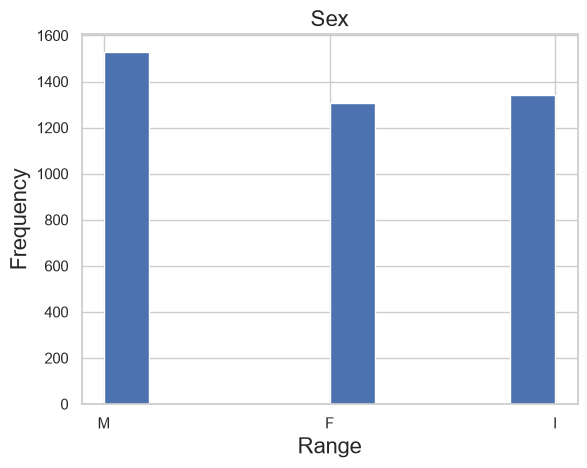

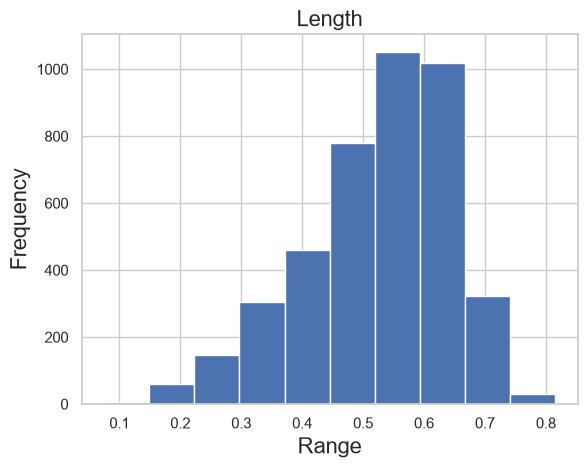

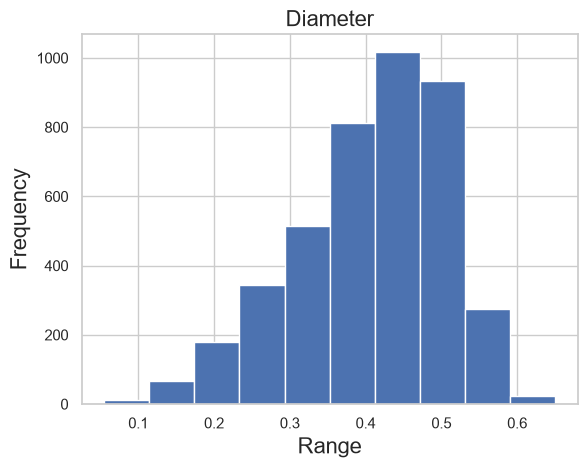

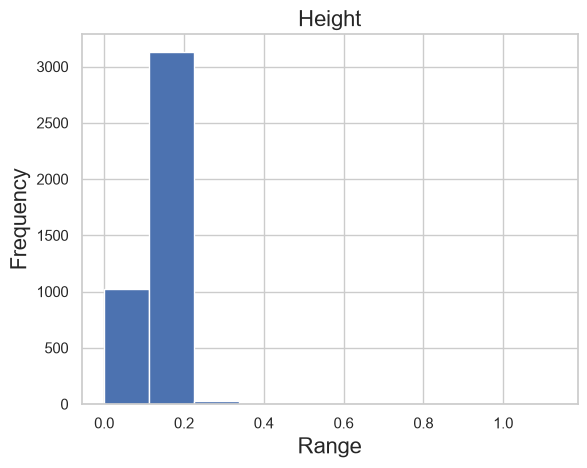

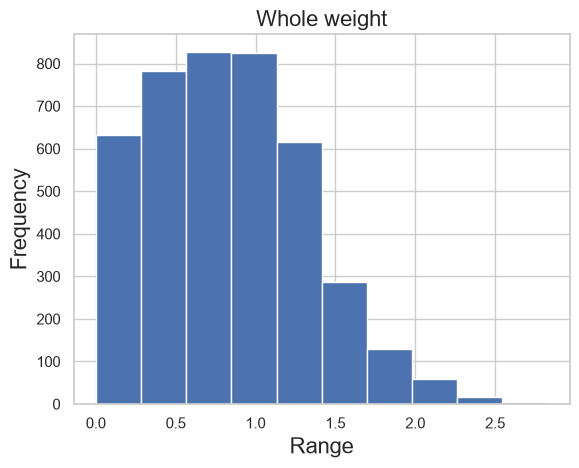

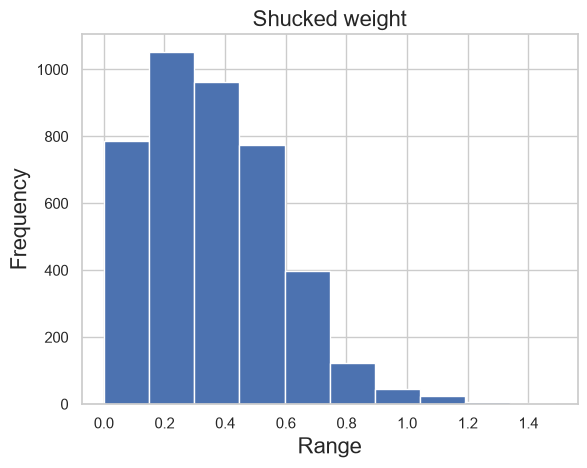

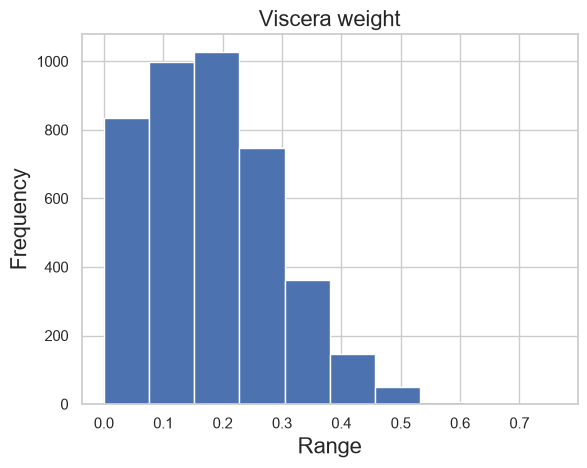

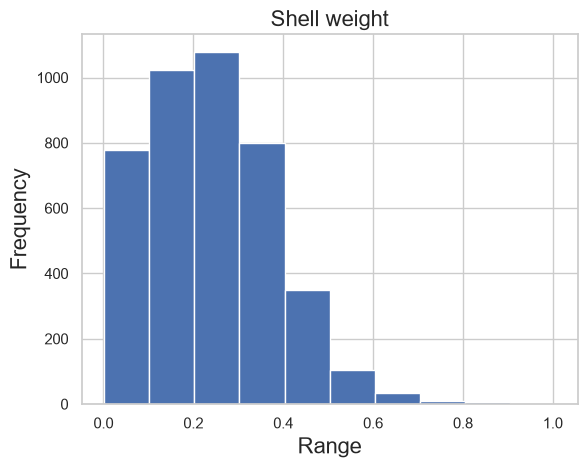

In [47]:
for name in cols[0:len(cols)-1]:
    plt.hist(abalone_data[name].values)
    plt.title(name,fontsize=16)
    plt.xlabel('Range',fontsize=16)
    plt.ylabel('Frequency',fontsize=16)
    plt.show()

Text(0, 0.5, 'Frequency')

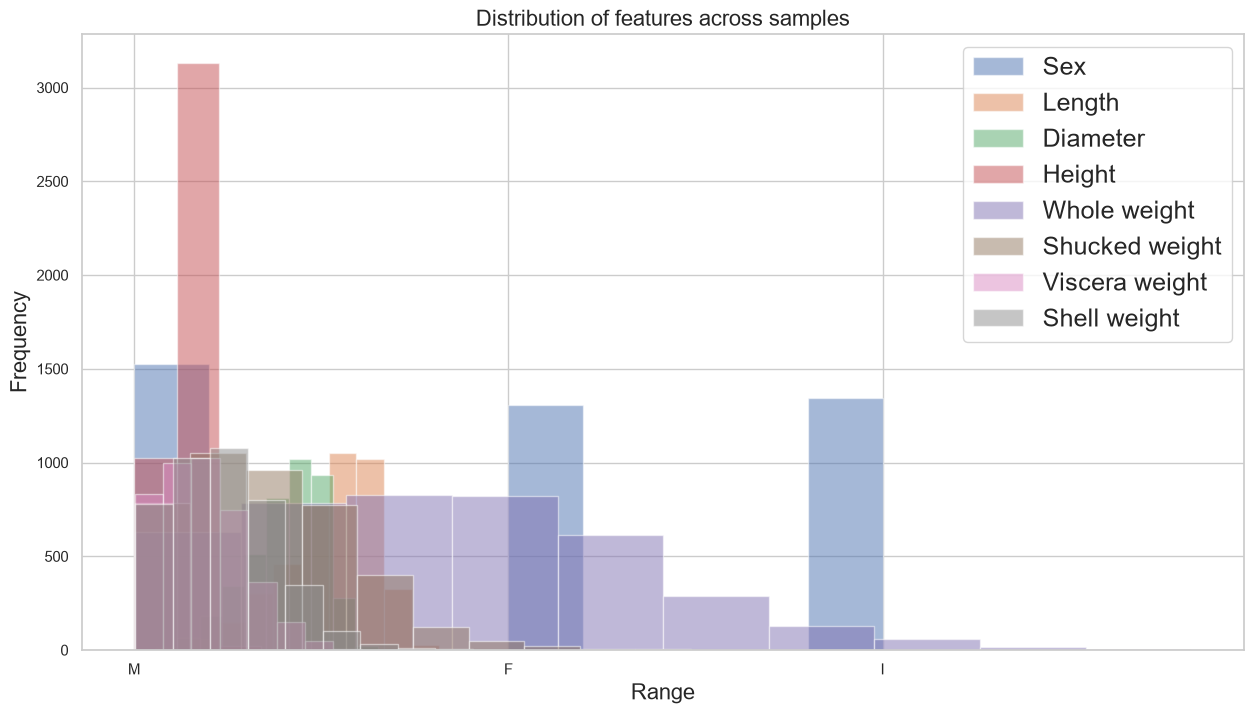

In [48]:
plt.figure(figsize=(15,8))
for c in abalone_data:
    plt.hist(abalone_data[c].values, alpha=0.5)

in_cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
plt.legend(in_cols,fontsize=18,loc="upper right",frameon=True)
plt.title("Distribution of features across samples",fontsize=16)
plt.xlabel('Range',fontsize=16)
plt.ylabel('Frequency',fontsize=16)

KDE PLOT

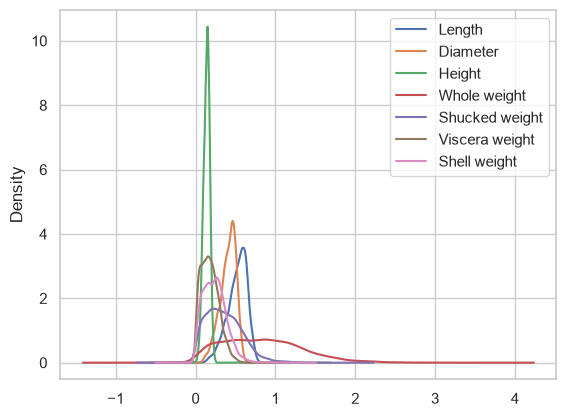

In [49]:
ax=abalone_data.plot.kde()

Box Plot

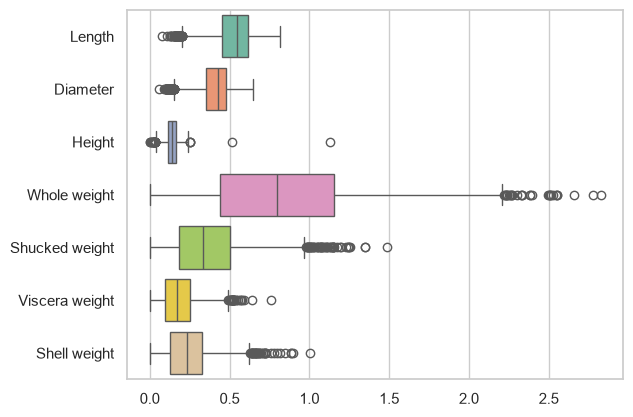

In [50]:
ax=sns.boxplot(data=abalone_data,orient="h",palette="Set2")

* Violin Plot

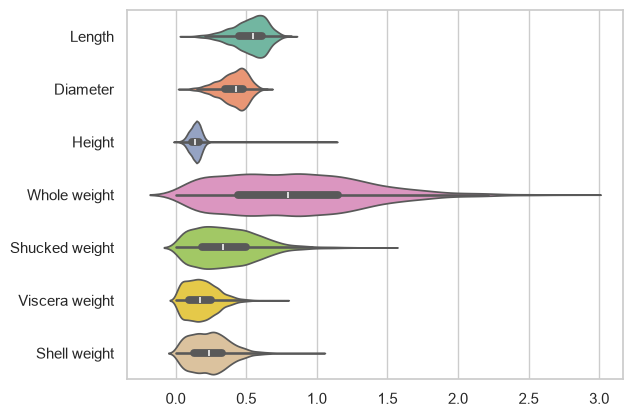

In [52]:
ax=sns.violinplot(data=abalone_data,orient="h",palette="Set2",density_norm="width")

Scaling

In [54]:
import numpy as np

In [59]:
x=np.array([4,5,2,-2,100]).reshape(-1,1)
x

array([[  4],
       [  5],
       [  2],
       [ -2],
       [100]])

In [60]:
from sklearn.preprocessing import MaxAbsScaler
mas=MaxAbsScaler()
x_new=mas.fit_transform(x)
print(x_new)

[[ 0.04]
 [ 0.05]
 [ 0.02]
 [-0.02]
 [ 1.  ]]


MinMaxScalar

In [64]:
from sklearn.preprocessing import MinMaxScaler
X=abalone_data.select_dtypes(include="number")
mms=MinMaxScaler()
X_norm = mms.fit_transform(X)
X_norm[:5]

array([[0.51351351, 0.5210084 , 0.0840708 , 0.18133522, 0.15030262,
        0.1323239 , 0.14798206],
       [0.37162162, 0.35294118, 0.07964602, 0.07915707, 0.06624075,
        0.06319947, 0.06826109],
       [0.61486486, 0.61344538, 0.11946903, 0.23906499, 0.17182246,
        0.18564845, 0.2077728 ],
       [0.49324324, 0.5210084 , 0.11061947, 0.18204356, 0.14425017,
        0.14944042, 0.15296462],
       [0.34459459, 0.33613445, 0.07079646, 0.07189658, 0.0595158 ,
        0.05134957, 0.0533134 ]])

In [65]:
X_norm.mean(axis=0)

array([0.60674608, 0.59307774, 0.12346584, 0.29280756, 0.24100033,
       0.23712127, 0.2365031 ])

In [66]:
X_norm.std(axis=0)

array([0.16226829, 0.16676972, 0.03701066, 0.17366046, 0.14925109,
       0.14430695, 0.13870055])